#### Final Exam – QRM
**Felipe Jaramillo**

## Problem 1:

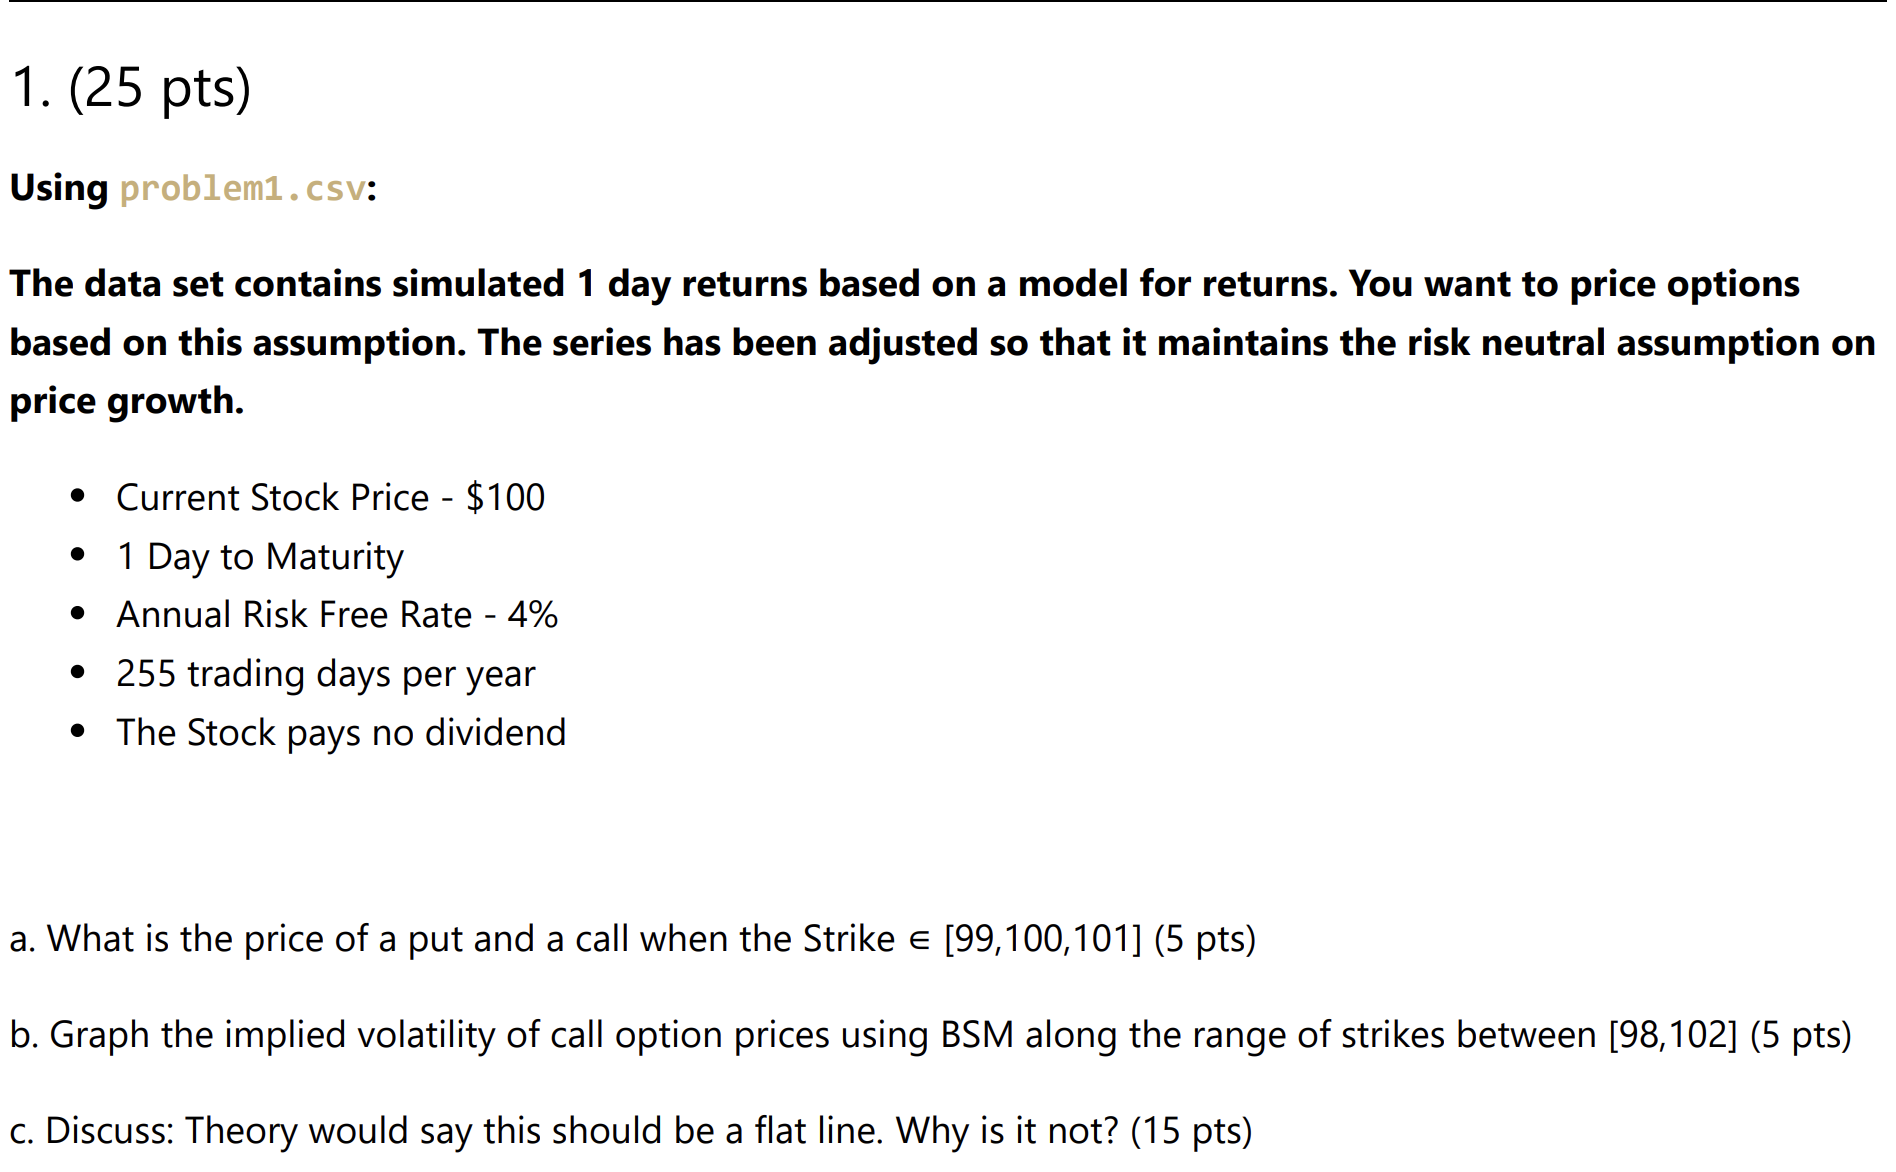

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import brentq
import matplotlib.pyplot as plt

returns = pd.read_csv('data/fn_problem1.csv')
returns

,r
0,0.001740
1,0.009059
2,0.000183
3,-0.010909
4,-0.002312
...,...
9995,-0.000060
9996,-0.001671
9997,0.000259
9998,0.004200


In [5]:
S0  = 100  # current stock price
rf  = 0.04 #(annual)
ttm = 1 / 255   # 1 trading day expressed as fraction of year (conceptually, like a 1-step binomial tree.)
                # no dividends
                
# Terminal prices: use log returns so S_T = S0 * e^r
# This is the standard assumption — log returns are normally distributed,
# meaning prices are lognormally distributed
S_T = S0 * np.exp(returns)

Part 1.a.


In [11]:
# ── Part 1: Price Put & Call for K ∈ [99, 100, 101] ──────────────────────────
# Each return is one possible outcome.
# Option price = e^{-rf*ttm} * E[payoff] where expectation = mean across scenarios.

def opt_call(sim, strike, rf, ttm):
    # payoff = max(S_T - K, 0), averaged across all simulated prices
    return np.exp(-rf * ttm) * np.mean(np.maximum(sim - strike, 0.0))

def opt_put(sim, strike, rf, ttm):
    return np.exp(-rf * ttm) * np.mean(np.maximum(strike - sim, 0.0))

# Fine grid: 0.01 spacing gives smooth curve in part 2
strikes = np.arange(98, 102.01, 0.01)
calls   = [opt_call(S_T, s, rf, ttm) for s in strikes]
puts    = [opt_put(S_T,  s, rf, ttm) for s in strikes]

print(f"{'Strike':>8} {'Call':>12} {'Put':>12}")
print("-" * 34)
for K in [99, 100, 101]:
    idx = np.argmin(np.abs(strikes - K))
    print(f"{strikes[idx]:>8.1f} {calls[idx]:>12.6f} {puts[idx]:>12.6f}")

  Strike         Call          Put
----------------------------------
    99.0     1.042896     0.025774
   100.0     0.195251     0.177972
   101.0     0.012603     0.995167


Part 1.b.

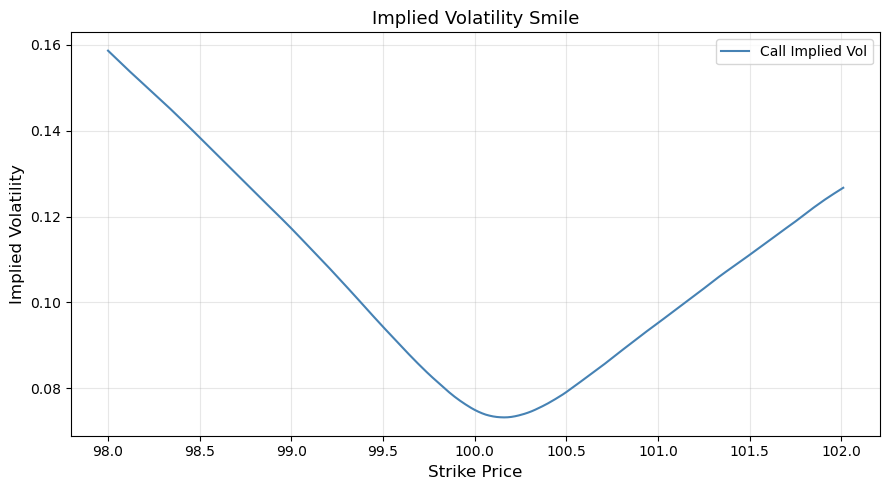

In [12]:
# ── Part 2: Implied Volatility Smile ─────────────────────────────────────────
# For each strike we have a simulated (empirical) call price.
# THe question is what constant BSM volatility would produce that exact price if BSM were the right model (normal returns),

def gbsm_call(S, K, T, r, sigma):
    """Standard BSM call price formula."""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * stats.norm.cdf(d1) - K * np.exp(-r*T) * stats.norm.cdf(d2)

def implied_vol(market_price, S, K, T, r):
    """Find sigma such that BSM price = market price (root finding)."""
    try:
        f = lambda iv: gbsm_call(S, K, T, r, iv) - market_price
        if f(1e-6) * f(10.0) > 0:   # brentq needs opposite signs at boundaries
            return np.nan
        return brentq(f, 1e-6, 10.0)
    except:
        return np.nan

# Annualized vol as initial guess: σ_daily * sqrt(255)
guess = np.std(returns) * np.sqrt(255)

call_iv = np.array([implied_vol(c, S0, s, ttm, rf) for s, c in zip(strikes, calls)])

plt.figure(figsize=(9, 5))
plt.plot(strikes, call_iv, color='steelblue', linewidth=1.5, label='Call Implied Vol')
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('Implied Volatility Smile', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Part 1.c.

The implied vol curve is not flat for several reasons.  
The main reason relies in the underlying assumptions of the BSM model, which are normally distributed returns (which implies longormal prices).
- Earlier in the class we reviwed kurtosis Excess kurtosis refers to (fat tails), i.e. more extreme outcomes occur than the normal distribution predicts. OTM options (both sides) have higher payoff probability than BSM expects, so their prices are higher. To match those prices, BSM needs a larger sigma, which in turns lifts both wings of the smile.
- Skew. As confirmed in our plot, the left tail is heavier than the right one. This is due to a well-observed phenomenon in finance: OTM puts are worth more than OTM calls at symmetric distances from spot. This is because there is a lot of demand for downside protection, referred to as NEGATIVE SKEW. This tilts the smile downward to the right rathern than producing a perfectly symmetric smile.

Together these effects mean no single volatility can fit all strikes, which is the fundamental limitation of BSM in practice, and the reason why it's not flat.

## Problem 2:

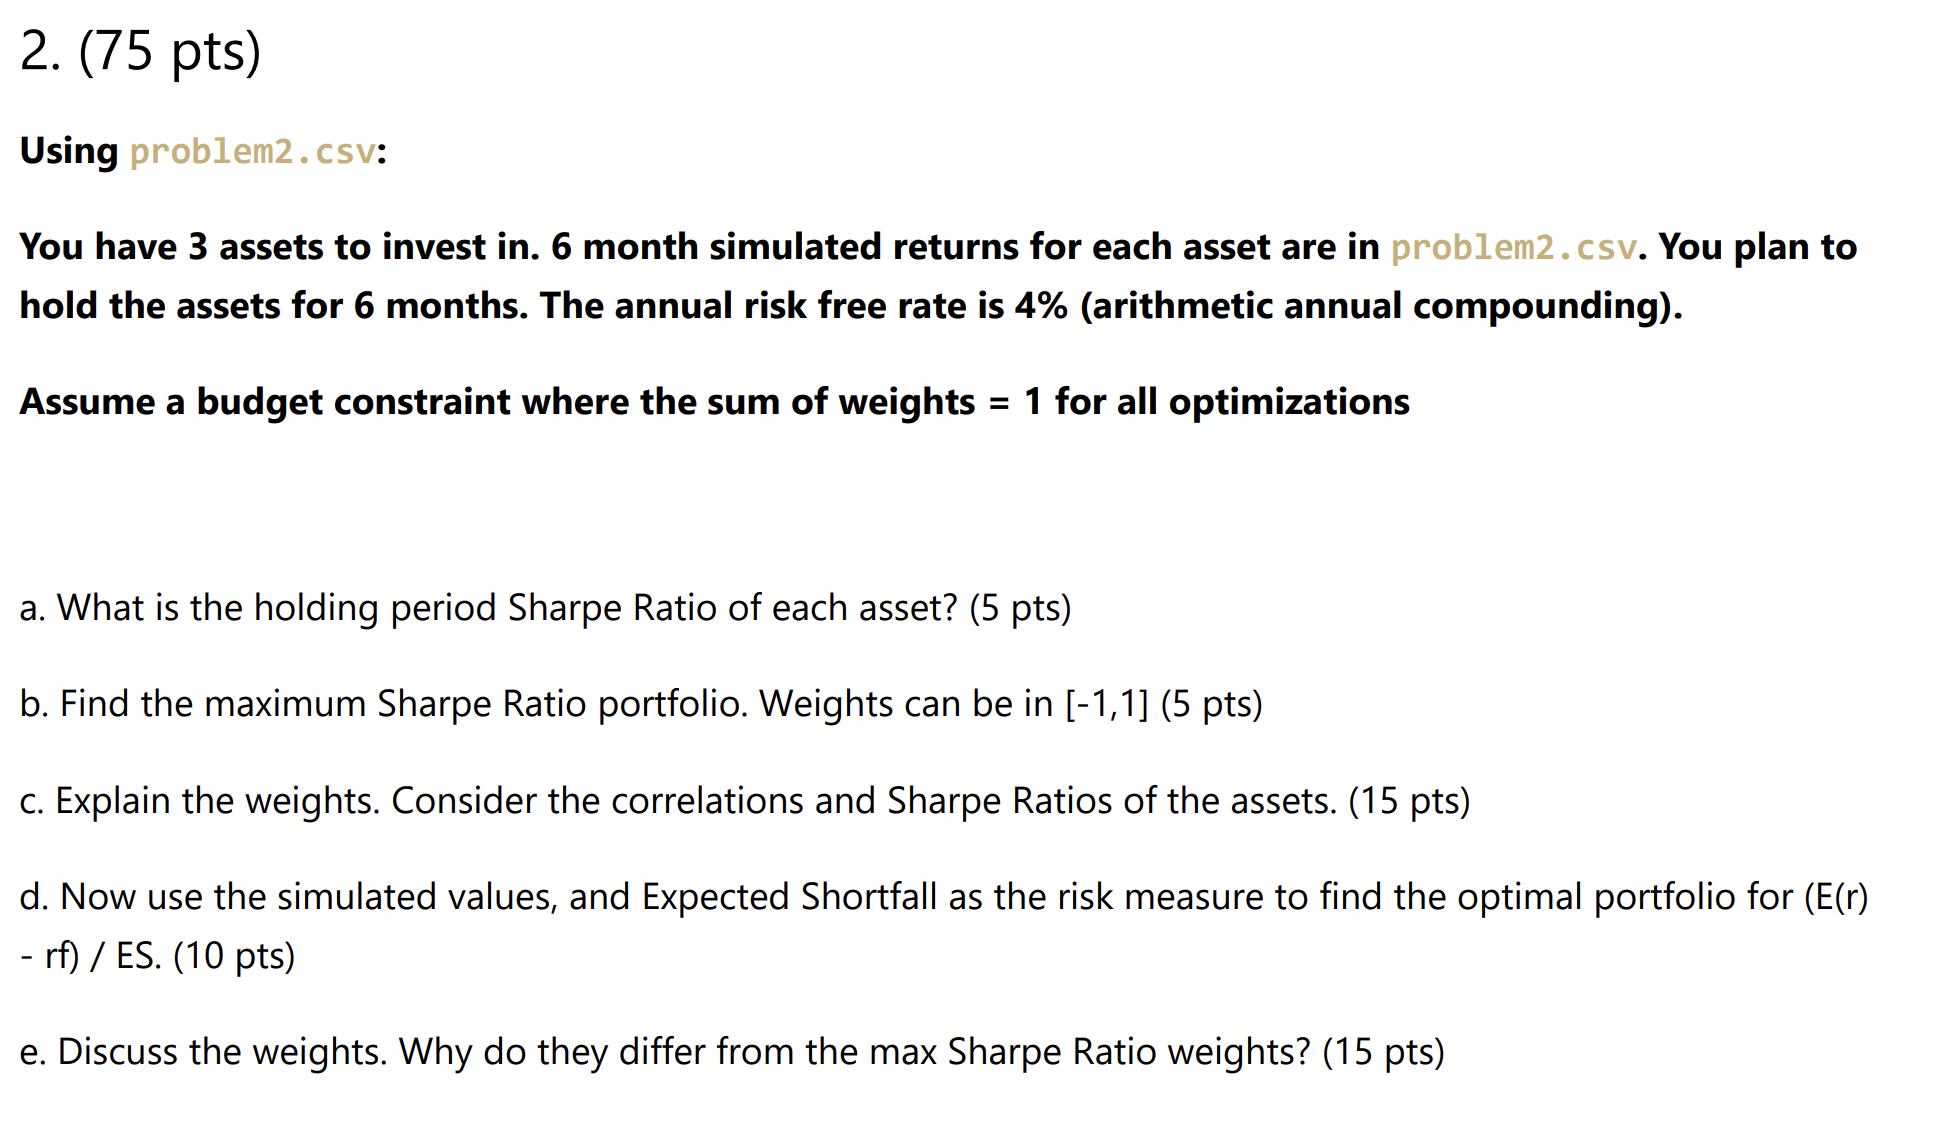

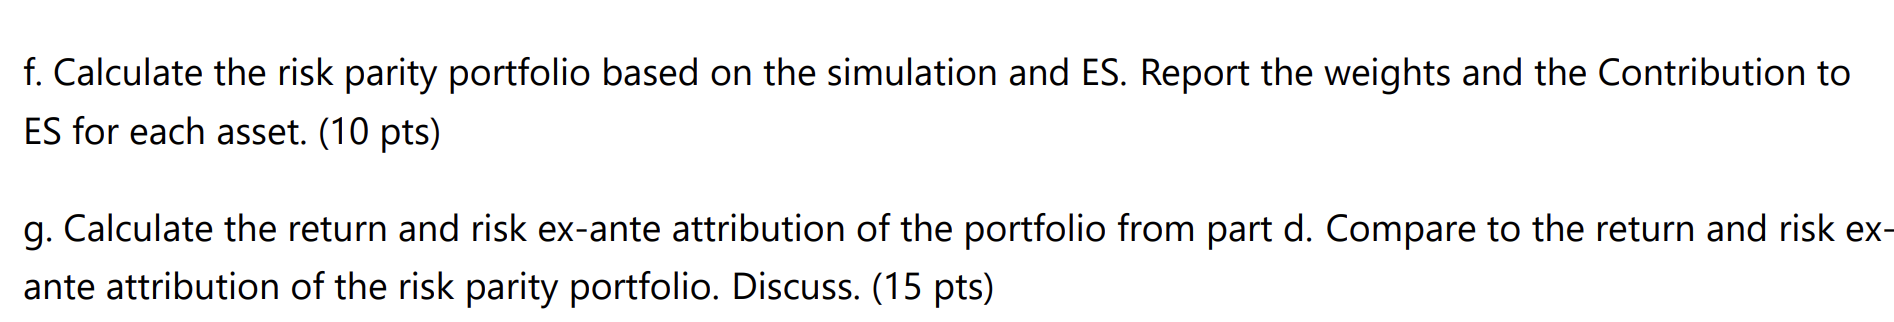


Part 2.a.:

In [68]:
# Setup
df = pd.read_csv('data/fn_problem2.csv') # 6-month simulated returns for each asset
df

,a,b,c
0,0.068992,0.090322,-0.222463
1,0.113488,0.138645,-0.616300
2,0.180086,0.217307,0.404441
3,-0.190042,-0.210383,0.020422
4,-0.018018,0.000147,0.616983
...,...,...,...
995,0.036894,0.057096,0.525503
996,-0.095151,-0.085575,0.301591
997,-0.108815,-0.102708,0.009846
998,0.200875,0.246184,0.608856


In [69]:
rf = 0.04 # risk free rate = 4% annual, arithmetic annual compunding
# holding for 6 moths, budget constraint all wieghts sum up to 1 (no leverage)
rf_n = rf/2 # this is the risk free rate for only 6mo since its quoted anually



a. Holding period Sharpe Ratio of each asset

In [70]:
sharpe_A = (np.mean(df['a']) - rf_n) / np.std(df['a'])
sharpe_B = (np.mean(df['b']) - rf_n) / np.std(df['b'])
sharpe_C = (np.mean(df['c']) - rf_n) / np.std(df['c'])

print('A:', sharpe_A)
print('A:', sharpe_B)
print('A:', sharpe_C)


A: 0.1112560820711566
A: 0.27767453158407457
A: 0.8888558807351219


Part 2.b.  
Find the maximum sharpe ratio protfolio (shorting allowed)

In [71]:
import numpy as np
from scipy.optimize import minimize

# create the correlation matrix for our assets
corr = df.corr()

# compute each asset's standard deviation
A1 = df['a']
A2 = df['b']
A3 = df['c']
sd = np.array([np.std(A1), np.std(A2), np.std(A3)])

# Expected return of each asset, E[R_i]
er = np.array([np.mean(A1), np.mean(A2), np.mean(A3)])

# Now we calculate the covariance matrix ourselves
cov = np.diag(sd) @ corr @ np.diag(sd)   # covariance matrix, Cov(i,j)=ρij​⋅σi​⋅σj​

# recall, this problem is also a minimizing variance problem
def min_variance(target_return):
    n = len(er) # number of assets
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},           # weights sum to 1,   ∑​w_i ​− 1 = 0
                   {'type': 'eq', 'fun': lambda w: w @ er - target_return}    # hit target return, w^⊤•μ − R = 0
                  ]

    bounds   = [(-1, 1)] * n                                     # shorting allowed: [(-1, 1), (-1, 1), ..., (-1, 1)] 
                                                                   # For each weight 𝑤𝑖 SLSQP enforces: -1 ≤ 𝑤𝑖 < 1 
    w0       = np.ones(n) / n                                      # equal weight start (𝑤𝑖 = 1/n)
    
    # Minimize portfolio variance: w^T Σ w
    result   = minimize(lambda w: w @ cov @ w,      # objective: minmize variance over combinations of w0
                        w0,                         # initial values (starting point)
                        method='SLSQP', 
                        bounds=bounds, 
                        constraints=constraints)
     
    # we're asking our def min_variance() func to return a dictionary with {'risk': ..., 'weights': ..., 'return': ...} :
    return {'risk': result.fun,  # minimized variance (risk)    
            'weights': result.x, # optimal asset weights
            'return': target_return} # target return used

# Range of target returns to trace out the efficient frontier
returns   = np.linspace(0.01, 0.2999, 500) # E[R] of each stock was between 3%-5%, therefore it can't be higher without shorting.

# Solve optimization for each target return
frontier  = [min_variance(r) for r in returns]

frontier_results = pd.DataFrame(frontier)
frontier_results

,risk,weights,return
0,0.013378,"[1.0, 0.09299946918403812, -0.09299946918403805]",0.010000
1,0.013259,"[1.0, 0.09043739488314922, -0.09043739488314928]",0.010581
2,0.013142,"[1.0, 0.08787532108912438, -0.08787532108912442]",0.011162
3,0.013026,"[0.9999999999999999, 0.08531324608115276, -0.0...",0.011743
4,0.012911,"[1.0, 0.08275117171352431, -0.08275117171352425]",0.012324
...,...,...,...
495,0.083184,"[-0.9924865788974689, 1.0, 0.9924865788974689]",0.297576
496,0.083582,"[-0.9948334127124671, 1.0, 0.9948334127124671]",0.298157
497,0.083980,"[-0.9971802477310254, 1.0, 0.9971802477310254]",0.298738
498,0.084379,"[-0.9995270821970188, 1.0, 0.9995270821970188]",0.299319


In [72]:
# These are the expected returns of each asset, ~ 3%, 5%, 27%
# If i were to not allow shorting, max return would be 27.8%, provided that we do allow it, then max return would be 27.8% + 5.1% - 3.1% = ~29.8% (upper bound)
er

array([0.03108805, 0.05188482, 0.27863934])

In [73]:
sd

array([0.09966241, 0.11482804, 0.29098006])

In [45]:
corr

,a,b,c
a,1.000000,0.995976,-0.080461
b,0.995976,1.000000,-0.077787
c,-0.080461,-0.077787,1.000000


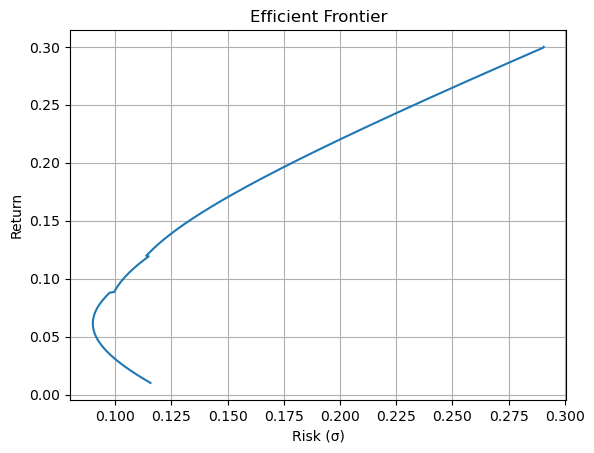

In [42]:
# plotting it
# Extract risk (std dev) and return
risks = [np.sqrt(p['risk']) for p in frontier]  # std dev = sqrt(variance)
rets  = [p['return'] for p in frontier]

# Plot efficient frontier
plt.figure()
plt.plot(risks, rets)
plt.xlabel('Risk (σ)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.grid(True)
plt.show()

In [50]:
# max sharpe ratio portfolio

# compute sharpe ratior for each portfolio E[R_p] - rf / sigma_portfolio
sharpe_ratios = [(p['return'] - 0.04) / np.sqrt(p['risk']) for p in frontier]
max_sr_idx    = np.argmax(sharpe_ratios)
max_sr_port   = frontier[max_sr_idx]
print(f"Max SR weights: {max_sr_port['weights']}")
print(f"Max SR return : {max_sr_port['return']:.4f}")
print(f"Max SR risk   : {np.sqrt(max_sr_port['risk']):.4f}")


Max SR weights: [-0.73902844  1.          0.73902844]
Max SR return : 0.2348
Max SR risk   : 0.2161


In [49]:
# corollary (potential error):
# The sharpe ratio is usually in APR (annuall percentage, semiannually compounded). In the above cell we subracted rf= 0.04 to compute the sharpe ratio, but this is 6-month period! So, in that case the rf for the 6-month caluclation would be halfed.

# However, I wont do that as we assume the model that was used to simulate returns already accounted for this.

Part 2.c. (discussion)
Explain the weights, consider the correlations and sharpe ratios of the assets.

Assuming the implementation is correct, the results are interesitng (perhaps a little agressive) – suggesting that most we should short asset a, invest the cash from the shorting in asset c, and our starting cash in asset b.

Max SR weights: [-0.73902844  1.          0.73902844]

So if we have $1 of starting capital, we should sell (-) $0.7390284 of asset a, invest that cash $0.7390284 in asset c, and put our initial $1 in asset b.

The standard deviations of these assets are approximately 9%, 11%, and 29% respectively. 

Consider the correlations:

In [47]:
corr

,a,b,c
a,1.000000,0.995976,-0.080461
b,0.995976,1.000000,-0.077787
c,-0.080461,-0.077787,1.000000


Asset a and b are extremely correlated, asset a and c have slighly storng inverse correlation, and asset b and c do as well. Therefore, it makes sense to conclude that having both asset a and b will expose you to a similar idiosyncratic risk (which is deiversifiable), and asset's A E[r_a] is the weakest. Therefore, asset a and c give exposure to different sources of risk while providing the strongest returns (in expectation).


Part 2.d.
Now use simulated values and ES: E[r] - rf / ES  as the risk measure to find the optimal portfolio

In [ ]:
# compute ES from simulated returns (as in notes)

# n_assets = 3
# w0 = np.ones(n_assets) / n_assets # we're starting with equal weights
# bounds   = [(-1, 1)] * n_assets
# constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},           # weights sum to 1,   ∑​w_i ​− 1 = 0
#                {'type': 'eq', 'fun': lambda w: w @ er - target_return}    # hit target return, w^⊤•μ − R = 0
# ]


def es_from_returns(port_r, alpha=0.05): 
    # ES at 95% confidence
    cutoff = np.percentile(port_r, alpha * 100)
    return -np.mean(port_r[port_r <= cutoff])

def portfolio_es(w, R, rf, alpha=0.05):
    port_r = R @ w
    er = np.mean(port_r)
    es = es_from_returns(port_r, alpha)
    if es < 1e-10:
        return 0.0
    return -((er - rf) / es)

target_return   = np.linspace(0.01, 0.2999, 500)
n = len(er) # number of assets
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},           # weights sum to 1,   ∑​w_i ​− 1 = 0
                   {'type': 'eq', 'fun': lambda w: w @ er - target_return}    # hit target return, w^⊤•μ − R = 0
                  ]

bounds   = [(-1, 1)] * n                                     # shorting allowed: [(-1, 1), (-1, 1), ..., (-1, 1)] 
                                                                   # For each weight 𝑤𝑖 SLSQP enforces: -1 ≤ 𝑤𝑖 < 1 
w0       = np.ones(n) / n                                      # equal weight start (𝑤𝑖 = 1/n)

# Use same optimization (replacing variance) by ES parametriczation
res_es = minimize(portfolio_es, w0, args=(R, rf_n),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  )

w_es    = res_es.x
es_ratio_opt = -portfolio_es(w_es, R, rf_n)

print("Max (E[r]-rf)/ES Portfolio:")
print(f"{'Asset':>10} {'Weight':>10}")
for asset, w in zip(assets, w_es):
    print(f"{asset:>10} {w:>10.4f}")
print(f"\nPortfolio (E[r]-rf)/ES ratio: {es_ratio_opt:.4f}")

ValueError: negative dimensions are not allowed

Part 2.e.

Assets with higher individual SR get larger positive weights.
- Negatively correlated asset pairs are combined to diversify risk: going long one and short the other reduces portfolio variance.
- An asset with a very low SR may receive a negative (short) weight if it is positively correlated with high-SR assets, since shorting it reduces risk without proportionally reducing expected return

From lecture:
When to NOT choose max SR: when returns are non-normal (e.g. selling options). SR doesn't capture tail risk and for example in this case we use ES instead.

Part 2.f.

Part 2.g.

## Problem 3:

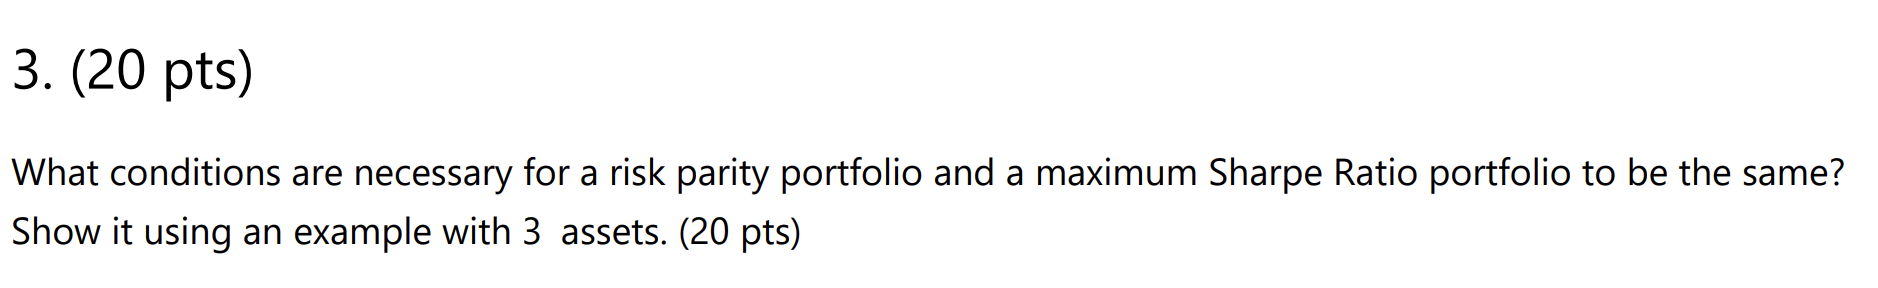

From lecture notes:

**Why Risk Parity Gets Used in Practice**

The key theoretical justification: if you believe that in the long run all assets have approximately equal Sharpe ratios (which is an equilibrium argument — investors bid up high-SR assets until their SR falls), and if correlations are roughly equal, then the risk parity portfolio is also the **maximum Sharpe ratio portfolio**. You get the super-efficient portfolio without having to estimate means at all — only volatilities and correlations, which are more stable and easier to forecast. Bridgewater Associates, one of the largest hedge funds in the world, is famous for using risk parity across asset classes for exactly this reason.

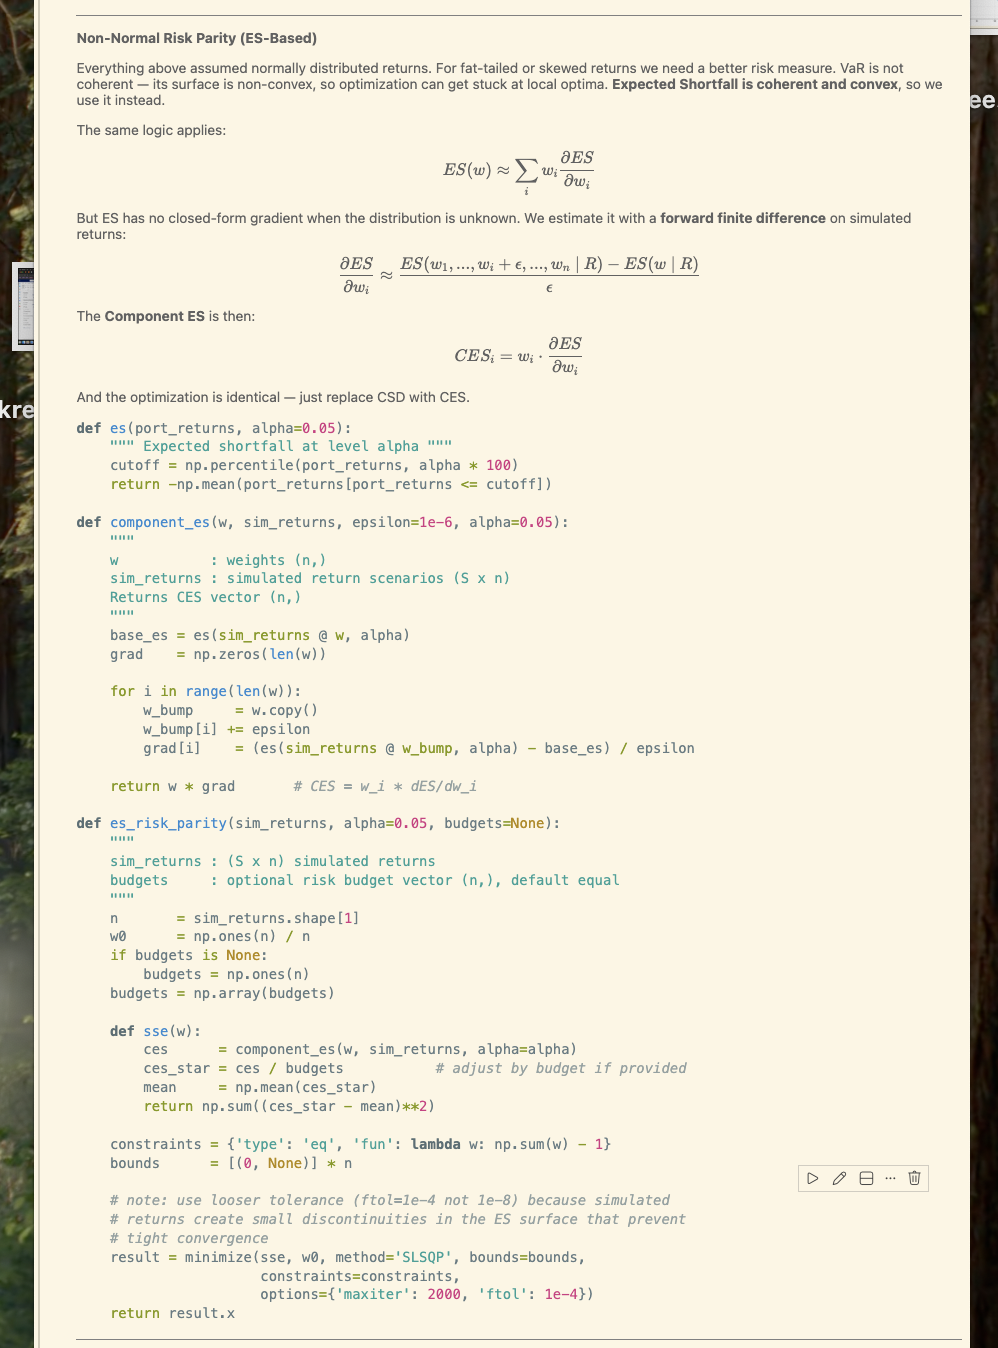

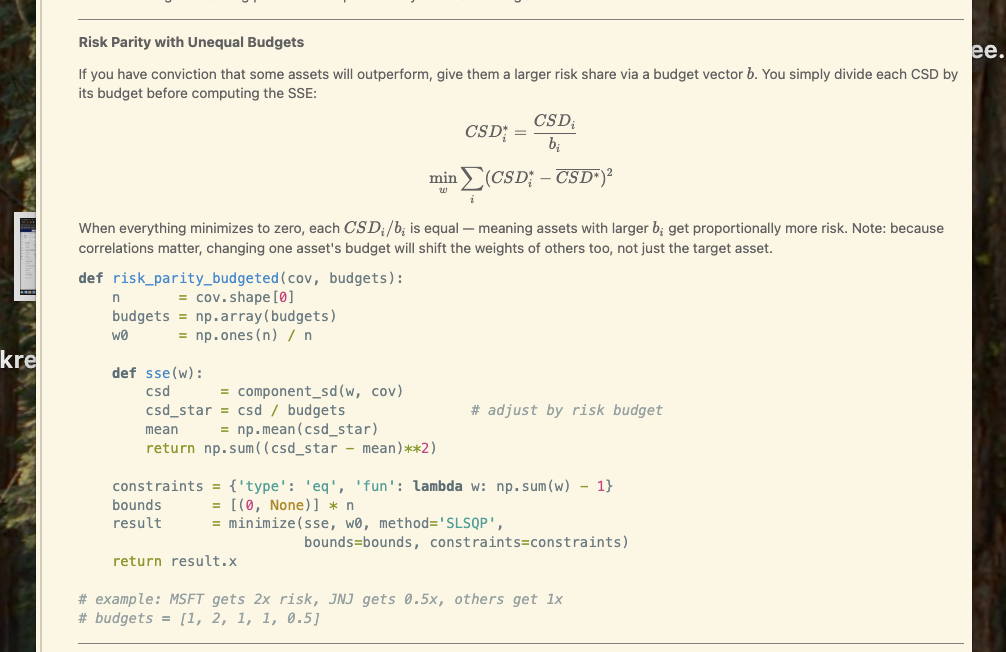 

From Notes (example QRM Notebook): Condition for Risk Parity to equal Max Sharpe Ratio:
  1. All pairwise correlations are equal
  2. All Sharpe Ratios are equal

3-Asset Example: equal correlations (rho=0.3), equal Sharpe Ratios (SR=0.5)

Vols  : [0.1  0.15 0.2 ]
means   : [0.07  0.095 0.12 ]
SRs   : [0.5 0.5 0.5]

Asset1     Asset2     Asset3  
Max SR weights {    0.4617     0.3046     0.2338}  
Risk Parity w   {  0.4615     0.3077     0.2308}  



Under equal correlations and equal Sharpe Ratios, both portfolios are identical. Risk parity gives the same result without needing to estimate expected returns.
This is the theoretical justification for using risk parity in practice — if you believe long-run SR equilibrium holds, you get the efficient portfolio
while avoiding the estimation error inherent in forecasting returns.